In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')   # add this line

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
import requests

# Download Hamlet text from Project Gutenberg
url = "https://www.gutenberg.org/files/2265/2265-0.txt"
text = requests.get(url).text

print("Downloaded characters:", len(text))


Downloaded characters: 171696


In [6]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Tokenize + clean
tokens = word_tokenize(text.lower())
stop_words = set(stopwords.words("english"))

# Keep alphabetic tokens only, remove stopwords
clean_words = [w for w in tokens if w.isalpha() and w not in stop_words]

print("Total tokens:", len(tokens))
print("Clean words (after stopwords):", len(clean_words))


Total tokens: 37180
Clean words (after stopwords): 15698


In [7]:
from collections import Counter

counts = Counter(clean_words)
top20 = counts.most_common(20)

# Show the 20 most common words + counts
top20


[('ham', 337),
 ('lord', 211),
 ('haue', 175),
 ('king', 173),
 ('shall', 107),
 ('come', 106),
 ('let', 104),
 ('thou', 104),
 ('hamlet', 100),
 ('good', 98),
 ('hor', 95),
 ('thy', 90),
 ('enter', 85),
 ('oh', 81),
 ('like', 78),
 ('well', 70),
 ('may', 69),
 ('know', 69),
 ('would', 68),
 ('selfe', 67)]

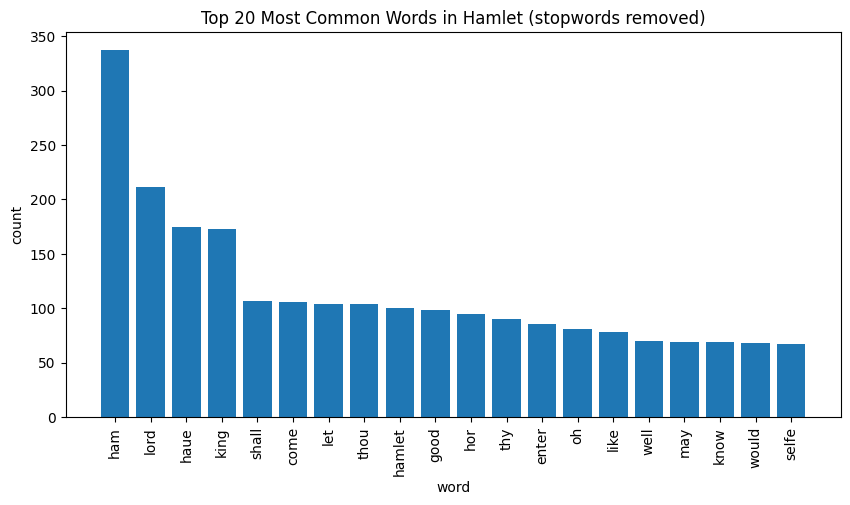

In [8]:
import matplotlib.pyplot as plt

labels = [w for w, c in top20]
values = [c for w, c in top20]

plt.figure(figsize=(10,5))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.xlabel("word")
plt.ylabel("count")
plt.title("Top 20 Most Common Words in Hamlet (stopwords removed)")
plt.show()


In [9]:
# Auto-generate a short conclusion paragraph based on your actual results
top_words = ", ".join([w for w, c in top20[:5]])
predominant = top20[0][0]
pred_count = top20[0][1]

conclusion = (
    f"I downloaded Shakespeare’s Hamlet from Project Gutenberg, tokenized the text, "
    f"removed punctuation and common English stopwords, then counted word frequencies. "
    f"The most frequent words included {top_words}. "
    f"The single most common word was '{predominant}' (count = {pred_count}). "
    f"This suggests that character names/titles and common archaic terms appear repeatedly throughout the play."
)

print(conclusion)


I downloaded Shakespeare’s Hamlet from Project Gutenberg, tokenized the text, removed punctuation and common English stopwords, then counted word frequencies. The most frequent words included ham, lord, haue, king, shall. The single most common word was 'ham' (count = 337). This suggests that character names/titles and common archaic terms appear repeatedly throughout the play.
